# MWE: a rapidly rotating star seen by CHARA, with `GravityDarkenedStar`

This notebook simulates CHARA-like interferometry of a rapidly rotating star and retrieves its size, spin and orientation with virgil. The model, `virgil.models.GravityDarkenedStar`, is **Shashank Dholakia's** JAX implementation of the Espinosa Lara and Rieutord (2011, A&A 533, A43; "ELR11") rotating-star model, ported into virgil from his `jax-interferometry` code, and the surface physics here is his work. You should come away knowing what the parameters mean and how to fit them with the same `fit` call as any other model.

A fast spinner is not a sphere. Write $\omega = \Omega/\Omega_K$ for its spin as a fraction of the critical rate at which gravity and the centrifugal force balance at the equator. The star becomes a Roche spheroid with $R_\mathrm{eq}/R_\mathrm{pole} = 1 + \omega^2/2$, so at $\omega = 0.92$ it is about 42 percent wider than it is tall.

Gravity is weaker at the equator, so the equator is cooler and fainter than the poles: this is gravity darkening. Von Zeipel's law, $T \propto g^\beta$ with $\beta = 1/4$, over-predicts the effect for fast rotators, and interferometric fits to stars like Altair find smaller $\beta$. ELR11 needs no free $\beta$, because they derive the flux from the requirement that it is anti-parallel to the effective gravity.

An interferometer sees this in three ways. $V^2$ shows the flattening, with the star larger perpendicular to the spin axis. For inclinations below 90 degrees the bright visible pole makes the image lopsided, which gives non-zero closure phases and fixes the pole's position angle over 360 degrees. And the contrast is chromatic, stronger in the blue, so giving the pole's temperature `t_pole` switches on a mode in which every patch radiates as a black body.

We take an Altair-like truth, inspired by Monnier et al. (2007, Science 317, 342) but not a reproduction of it: 3.3 mas across the equator, $\omega = 0.92$, inclination 56 degrees, the pole at position angle 298 degrees (62 degrees West of North), and a polar temperature of 8500 K. The plot shows its visible surface, with East to the left and North up.

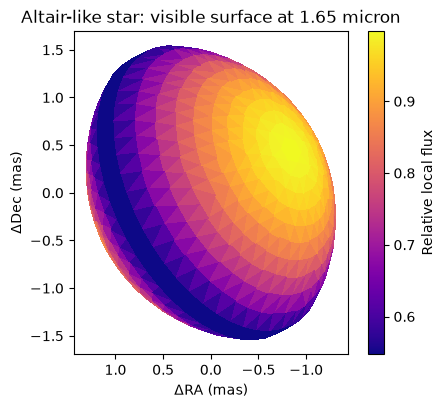

In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpyro.distributions as dist

from virgil.coverage import vlti_oidata
from virgil.fitting import fit
from virgil.inference import laplace_cov
from virgil.models import GravityDarkenedStar
from virgil.plotting import (
    plot_data_model_correlation,
    plot_model,
    plot_residual_map,
)

truth = GravityDarkenedStar(
    3.3, omega=0.92, inc=56.0, pa=298.0, t_pole=8500.0, n_lat=24
)
fig, ax = plt.subplots(figsize=(5, 4.2))
truth.plot_surface(ax=ax)
ax.set_title("Altair-like star: visible surface at 1.65 micron")
plt.show()

The bright patch is the visible pole, towards the upper right because its position angle is 298 degrees, and the dark belt below it is the gravity-darkened equator. The outline is the Roche spheroid projected on the sky. We use a coarse mesh of 24 latitude rings throughout to keep the visibilities cheap, which is why the triangles show.

CHARA has six telescopes on Mount Wilson (latitude +34.224 degrees) and baselines up to about 330 m, so we give `vlti_oidata` its approximate (East, North) station positions in metres from S1. We observe Altair (declination +8.87 degrees) at five hour angles, in eight H-band channels from 1.50 to 1.74 microns as for MIRC-X, with errors of 0.01 on $V^2$ and 0.75 degrees on the closure phases. `with_model` fills the dataset with the truth's observables plus seeded noise, and the printed line summarises it.

In [2]:
chara = [  # (East, North) in metres relative to S1
    (0.0, 0.0),
    (-5.75, 33.58),
    (125.33, 305.93),
    (70.39, 269.72),
    (-175.07, 216.33),
    (-69.09, 199.34),
]
template = vlti_oidata(
    chara,
    declination_deg=8.87,
    latitude_deg=34.224,
    hour_angles_h=(-3.0, -1.5, 0.0, 1.5, 3.0),
    wavelengths_m=np.linspace(1.50e-6, 1.74e-6, 8),
    sigma_v2=0.01,
    sigma_cp_deg=0.75,
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
u, v = (
    np.asarray(data.u / data.wavel) / 1e6,
    np.asarray(data.v / data.wavel) / 1e6,
)
print(
    f"{data.vis.size} V2 and {data.phi.size} closure phases, 8 channels, max B/lambda = {np.hypot(u, v).max():.0f} Mlambda"
)

600 V2 and 800 closure phases, 8 channels, max B/lambda = 220 Mlambda


To see what the baselines sample, we draw their tracks, in megawavelengths and with both signs, over the truth's $\log_{10} V^2$ computed from `truth.model` on a regular uv grid at 1.65 microns. The lobes are narrower along the star's long axis, which is the flattening, and the tracks reach well past the first null. The star's image is alongside for reference.

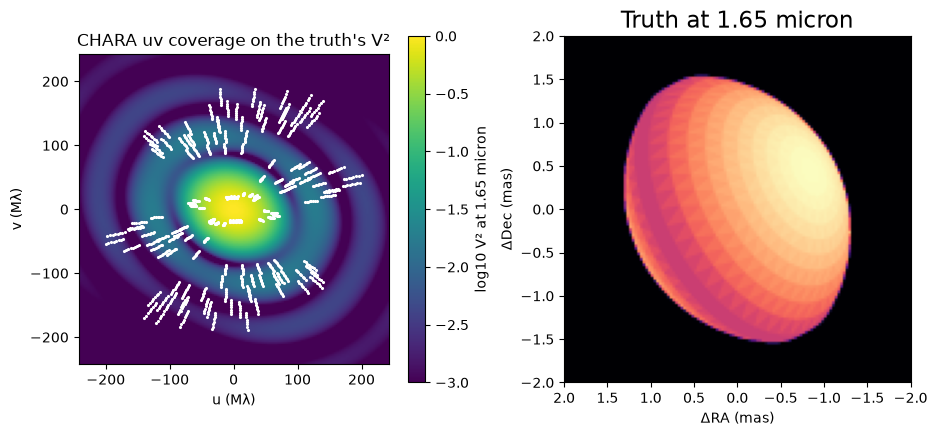

In [3]:
wavel0 = 1.65e-6
half = 1.1 * np.hypot(u, v).max()
g = np.linspace(-half, half, 181)
gu, gv = np.meshgrid(g, g)
vis0 = truth.model(
    gu.ravel() * 1e6 * wavel0, gv.ravel() * 1e6 * wavel0, wavel0
)
log_v2 = np.log10(np.abs(vis0).reshape(gu.shape) ** 2 + 1e-12)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4.5))
im = a0.imshow(
    log_v2,
    extent=[-half, half, -half, half],
    origin="lower",
    cmap="viridis",
    vmin=-3,
    vmax=0,
)
a0.plot(np.r_[u, -u], np.r_[v, -v], "w.", ms=2.5)
a0.set(
    xlabel="u (Mλ)",
    ylabel="v (Mλ)",
    title="CHARA uv coverage on the truth's V²",
)
fig.colorbar(im, ax=a0, label="log10 V² at 1.65 micron")
plot_model(truth, fov_mas=4.0, npix=128, ax=a1, title="Truth at 1.65 micron")
plt.show()

Next we plot the simulated observables. On the left is $V^2$ against spatial frequency, coloured by baseline position angle: a circular star would put every colour on one curve, so the scatter is the flattening. On the right are the closure phases, against the longest spatial frequency in each triangle. A centrosymmetric star has phases of exactly 0 or 180 degrees, so the departures from these are the signature of the bright pole.

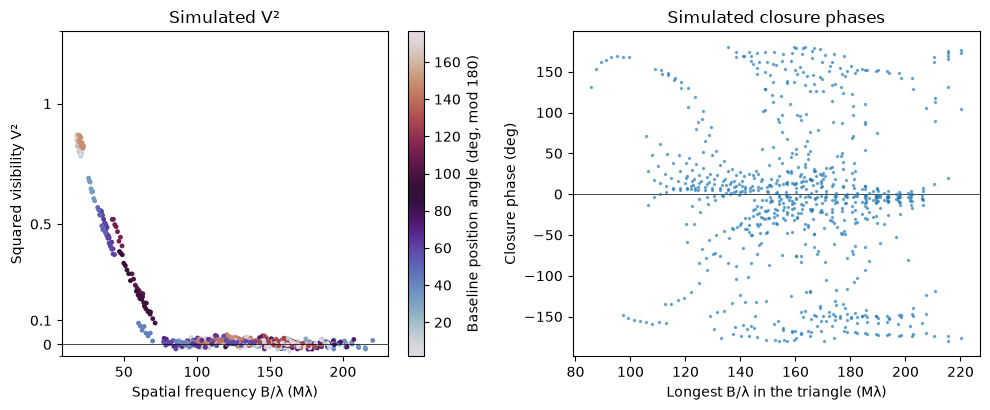

In [4]:
bl = np.hypot(u, v)
pa_bl = np.degrees(np.arctan2(u, v)) % 180
i1, i2, i3 = (np.asarray(i) for i in (data.i_cps1, data.i_cps2, data.i_cps3))
bl_cp = np.max([bl[i1], bl[i2], bl[i3]], axis=0)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 4.2))
sc = a0.scatter(bl, np.asarray(data.vis), c=pa_bl, s=6, cmap="twilight")
a0.axhline(0, color="k", lw=0.5)
a0.set(
    xlabel="Spatial frequency B/λ (Mλ)",
    ylabel="Squared visibility V²",
    yscale="symlog",
    ylim=(-0.05, 1.3),
    title="Simulated V²",
)
a0.set(yticks=[0, 0.1, 0.5, 1], yticklabels=["0", "0.1", "0.5", "1"])
fig.colorbar(sc, ax=a0, label="Baseline position angle (deg, mod 180)")
a1.errorbar(
    bl_cp,
    np.degrees(np.asarray(data.phi)),
    np.degrees(np.asarray(data.d_phi)),
    fmt=".",
    ms=3,
    lw=0.5,
    alpha=0.5,
)
a1.axhline(0, color="k", lw=0.5)
a1.set(
    xlabel="Longest B/λ in the triangle (Mλ)",
    ylabel="Closure phase (deg)",
    title="Simulated closure phases",
)
plt.tight_layout()
plt.show()

Now we retrieve the star. `fit` takes a Uniform prior on each of the diameter, rotation rate, inclination and pole position angle, and a deliberately wrong starting star, with the temperature and reference wavelength held fixed. `laplace_cov` then turns the curvature of the likelihood at the solution into a covariance, which we compute in double precision because the likelihood is so sharp. The table compares the truth with the fit.

In [5]:
priors = {
    "diam_eq": dist.Uniform(1.0, 8.0),
    "omega": dist.Uniform(0.0, 0.99),
    "inc": dist.Uniform(0.0, 90.0),
    "pa": dist.Uniform(0.0, 360.0),
}
start = GravityDarkenedStar(
    2.8, omega=0.5, inc=30.0, pa=250.0, t_pole=8500.0, n_lat=24
)
result = fit(start, priors, data)
names = list(priors)
with jax.enable_x64(True):
    best = np.array([float(result.values[k]) for k in names])
    cov = np.asarray(laplace_cov(best, names, data, start))
sig, corr = (
    np.sqrt(np.diag(cov)),
    cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov))),
)
print(f"{'':>8}{'truth':>10}{'start':>10}{'fit':>12}{'± sigma':>10}")
for i, k in enumerate(names):
    print(
        f"{k:>8}{float(getattr(truth, k)):10.3f}{float(getattr(start, k)):10.3f}{best[i]:12.4f}{sig[i]:10.4f}"
    )
print(
    f"chi2/N = {result.info['chi2_red']:.2f};  corr(omega, inc) = {corr[1, 2]:+.2f}, corr(diam_eq, omega) = {corr[0, 1]:+.2f}"
)

             truth     start         fit   ± sigma
 diam_eq     3.300     2.800      3.2995    0.0002
   omega     0.920     0.500      0.9199    0.0003
     inc    56.000    30.000     55.8848    0.0554
      pa   298.000   250.000    298.0162    0.0123
chi2/N = 1.03;  corr(omega, inc) = -0.46, corr(diam_eq, omega) = +0.72


The fit lands on the truth with a reduced chi-squared near one. The uncertainties are tiny because baselines reaching past the first null are very sensitive to size and shape; they exclude model error, which would dominate with real data, and here we fitted with the same mesh that made the data. The Laplace covariance is only a local Gaussian approximation, so we check it by sampling the posterior with NUTS through `numpyro_model`, with the same mesh. To make the sampler fast we sample in coordinates whitened by the Laplace covariance, in which the posterior is roughly a unit sphere; their prior is a broad normal (ten times wider than the posterior), so it is effectively flat, like the Uniform priors. The corner plot compares the samples with the Gaussian and marks the truth. Look for whether the Gaussian matches the posterior, and for the strong correlation between $\omega$ and the diameter and the weaker one between $\omega$ and the inclination.

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


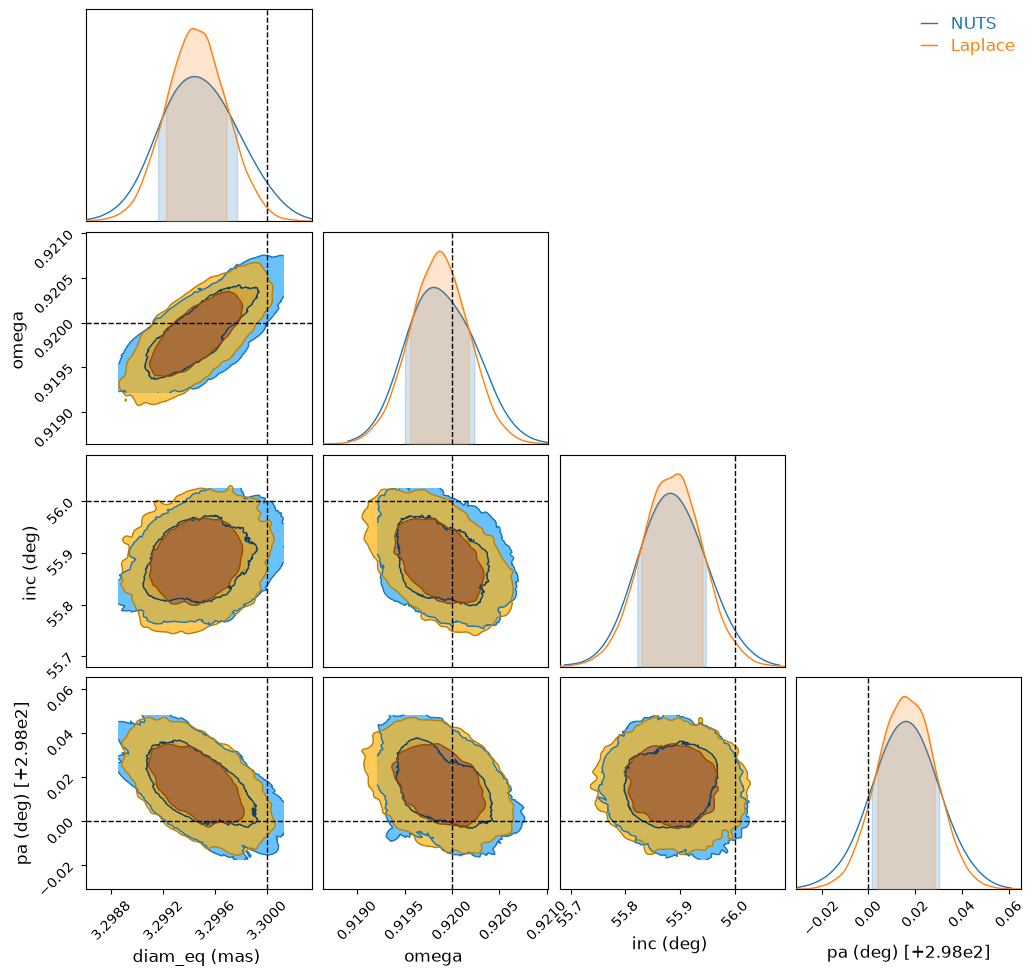

In [6]:
import logging

import jax.numpy as jnp
from chainconsumer import Chain, ChainConsumer, Truth
from numpyro.infer import MCMC, NUTS

from virgil.likelihood import numpyro_model
from virgil._precision import cast_tree

L = np.linalg.cholesky(cov)  # parameters = best + L @ z: z is about N(0, 1)


def star(**z):
    x = best + L @ jnp.stack([z[f"z{i}"] for i in range(4)])
    return GravityDarkenedStar(
        x[0], omega=x[1], inc=x[2], pa=x[3], t_pole=8500.0, n_lat=24
    )


with jax.enable_x64(True):
    # a prior 10x wider than the posterior: effectively flat
    z_priors = {f"z{i}": dist.Normal(0.0, 10.0) for i in range(4)}
    model = numpyro_model(star, z_priors, cast_tree(data, "float64"))
    mcmc = MCMC(
        NUTS(model), num_warmup=200, num_samples=300, progress_bar=False
    )
    mcmc.run(jax.random.PRNGKey(1))
    z = np.stack(
        [np.asarray(mcmc.get_samples()[f"z{i}"]) for i in range(4)], -1
    )
cols = ["diam_eq (mas)", "omega", "inc (deg)", "pa (deg)"]
gauss = np.random.default_rng(0).multivariate_normal(best, cov, 20000)
logging.getLogger("chainconsumer").setLevel(logging.ERROR)
cc = ChainConsumer()
cc.add_chain(
    Chain(
        samples=pd.DataFrame(best + z @ L.T, columns=cols),
        name="NUTS",
        color="#1f77b4",
        kde=1.0,  # Scott's-rule smoothing of the 300 samples
    )
)
cc.add_chain(
    Chain(
        samples=pd.DataFrame(gauss, columns=cols),
        name="Laplace",
        color="#ff7f0e",
    )
)
cc.add_truth(Truth(location=dict(zip(cols, [3.3, 0.92, 56.0, 298.0]))))
cc.plotter.plot()
plt.show()

We check the fit with `plot_data_model_correlation`, which plots the model against the data, with error bars and a one-to-one line, for $V^2$ on the left and closure phases in radians on the right. The fit is a point estimate, so we pass its predictions with zero spread. The points should lie on the line with scatter of the size of the error bars.

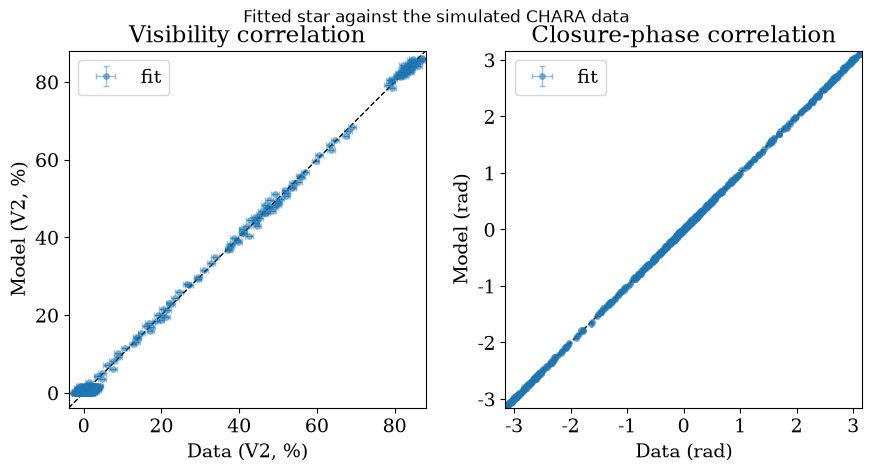

In [7]:
n_vis = data.vis.size
prediction = data.model(result.model)
summary = {
    "fit": {
        "vis_mean": prediction[:n_vis],
        "vis_std": 0 * prediction[:n_vis],
        "phi_mean": prediction[n_vis:],
        "phi_std": 0 * prediction[n_vis:],
    }
}
fig, _ = plot_data_model_correlation(
    data, summary, figsize=(9, 4.5), phase_title="Closure-phase correlation"
)
fig.suptitle("Fitted star against the simulated CHARA data", y=1.02)
plt.show()

Finally we render the truth and the fit on the same 4 mas grid of 128 pixels. The images have unit total flux, so the residual map, on a symmetric diverging scale, shows plain residuals (fit minus truth) and not z-scores. It should be very small.

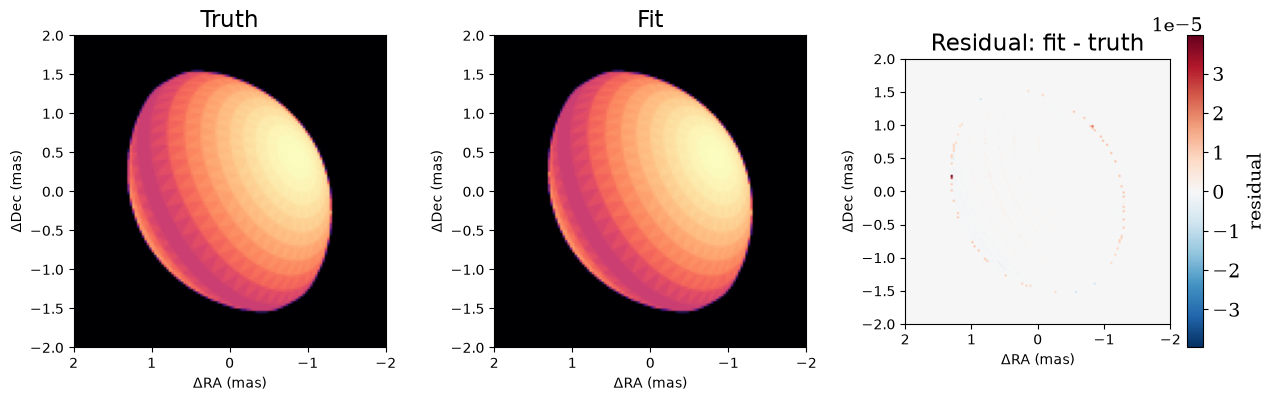

In [8]:
fov, npix = 4.0, 128
fit_star = result.model
residual = np.asarray(fit_star.render(npix, fov)) - np.asarray(
    truth.render(npix, fov)
)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_model(truth, fov, npix, ax=axes[0], title="Truth")
plot_model(fit_star, fov, npix, ax=axes[1], title="Fit")
plot_residual_map(residual, fov, ax=axes[2], title="Residual: fit - truth")
plt.tight_layout()
plt.show()

**Summary.** From 600 squared visibilities and 800 closure phases, `fit` recovered the star's diameter, rotation rate, inclination and pole position angle from a poor start, and the fitted image matches the truth. $V^2$ constrains the size and flattening, while the closure phases, which exist only because the hot pole makes the star lopsided, fix the pole's position angle over 360 degrees. The inclination and rotation rate stay correlated, and at lower resolution they would be measured only in combination.

To go further, see the `GravityDarkenedStar` docstring, in particular its chromatic mode, where `t_pole` and `wavel0` make the contrast depend on wavelength and let the star supply its own spectrum to a `System` with a companion. A re-analysis of Shashank's real CHARA/PAVO data is in progress in `examples/elr_pavo/`. References: Espinosa Lara and Rieutord (2011), A&A 533, A43; Monnier et al. (2007), Science 317, 342.